In [300]:
!pip install pandas scikit-learn numpy rlcmab-sampler



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [301]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


from rlcmab_sampler import sampler


# Load and Preprocess Users

In [302]:
def load_and_preprocess_users(path):
    df = pd.read_csv(path)

    # Normalize label case
    df["label"] = df["label"].str.lower()

    # Handle missing values
    df = df.ffill()

    encoders = {}

    # Encode categorical columns (except label)
    for col in df.select_dtypes(include="object").columns:
        if col != "label":
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le

    return df, encoders


In [303]:
df1 = pd.read_csv("/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv")
print(df1["label"].value_counts())

label
user1    687
user2    669
user3    644
Name: count, dtype: int64


In [304]:
df2 = pd.read_csv("/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv")
print(df1["label"].value_counts())

label
user1    687
user2    669
user3    644
Name: count, dtype: int64


# Training Context Classifier

In [305]:
# Removed

# Context to Arm Mapping

In [306]:
context_map = {
    "user1": 0,
    "user2": 1,
    "user3": 2
}

category_map = {
    "Entertainment": 0,
    "Education": 1,
    "Tech": 2,
    "Crime": 3
}

# Training and testing a randomforest classifier

In [307]:
def train_model(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    model = DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    return model, [train_acc], [val_acc]


'''def train_model(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Scale features (important for logistic regression)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        multi_class="auto"
    )

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    return model, scaler, [train_acc], [val_acc]
'''


'def train_model(df):\n\n    X = df.drop("label", axis=1)\n    y = df["label"]\n\n    X_train, X_val, y_train, y_val = train_test_split(\n        X, y,\n        test_size=0.2,\n        stratify=y,\n        random_state=42\n    )\n\n    # Scale features (important for logistic regression)\n    scaler = StandardScaler()\n    X_train = scaler.fit_transform(X_train)\n    X_val = scaler.transform(X_val)\n\n    model = LogisticRegression(\n        max_iter=1000,\n        multi_class="auto"\n    )\n\n    model.fit(X_train, y_train)\n\n    train_preds = model.predict(X_train)\n    val_preds = model.predict(X_val)\n\n    train_acc = accuracy_score(y_train, train_preds)\n    val_acc = accuracy_score(y_val, val_preds)\n\n    print("Train Accuracy:", train_acc)\n    print("Validation Accuracy:", val_acc)\n\n    return model, scaler, [train_acc], [val_acc]\n'

# Plotting charts

In [308]:
import matplotlib.pyplot as plt

def plot_training_curves(train_acc, val_acc):

    if len(train_acc) == 0 or len(val_acc) == 0:
        print("No training data to plot.")
        return

    epochs = list(range(1, len(train_acc) + 1))

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
    plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Testing

In [309]:
def test_model(model, encoders, test_path):

    df_test = pd.read_csv(test_path)

    # Normalize label case
    df_test["label"] = df_test["label"].str.lower()

    # Drop ID column
    if "user_id" in df_test.columns:
        df_test = df_test.drop("user_id", axis=1)

    # Fill missing values
    df_test = df_test.ffill()

    # Feature binning (same as training)
    df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")
    df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")
    df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")
    df_test["age"] = pd.qcut(df_test["age"], 8, labels=False, duplicates="drop")

    # Feature engineering
    df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)
    df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)

    X_test = df_test.drop("label", axis=1)
    y_test = df_test["label"]

    preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, preds)

    print("Test Accuracy:", test_acc)

    return test_acc


'''def test_model(model, scaler, encoders, test_path):

    df_test = pd.read_csv(test_path)

    # Normalize labels
    df_test["label"] = df_test["label"].str.lower()

    # Drop ID column
    if "user_id" in df_test.columns:
        df_test = df_test.drop("user_id", axis=1)

    # Fill missing values
    df_test = df_test.ffill()

    # Feature binning (same as training)
    df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")
    df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")
    df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")

    # Feature engineering (same as training)
    df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)
    df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)

    # Split features and labels
    X_test = df_test.drop("label", axis=1)
    y_test = df_test["label"]

    # Scale features
    X_test = scaler.transform(X_test)

    preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, preds)

    print("Test Accuracy:", test_acc)

    return test_acc'''


'def test_model(model, scaler, encoders, test_path):\n\n    df_test = pd.read_csv(test_path)\n\n    # Normalize labels\n    df_test["label"] = df_test["label"].str.lower()\n\n    # Drop ID column\n    if "user_id" in df_test.columns:\n        df_test = df_test.drop("user_id", axis=1)\n\n    # Fill missing values\n    df_test = df_test.ffill()\n\n    # Feature binning (same as training)\n    df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")\n    df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")\n    df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")\n\n    # Feature engineering (same as training)\n    df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)\n    df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)\n\n    # Split features and labels\n    X_test = df_test.drop("label", axis=1)\n    y_test = df_test["label"]\n\n   

# Plots

In [310]:
def plot_final_results(val_acc_history, test_acc):

    if len(val_acc_history) == 0:
        print("No validation history to plot.")
        return

    epochs = list(range(1, len(val_acc_history) + 1))

    plt.figure(figsize=(8,5))
    plt.plot(epochs, val_acc_history, marker="o", label="Validation Accuracy")

    # Draw horizontal test accuracy line
    plt.axhline(y=test_acc, linestyle="--", label=f"Test Accuracy ({test_acc:.3f})")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation vs Test Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Main flow 

In [311]:
def main():

    df, encoders = load_and_preprocess_users(
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"
    )

    # Normalize labels
    df["label"] = df["label"].str.lower()

    # Drop ID column
    if "user_id" in df.columns:
        df = df.drop("user_id", axis=1)

    # Fill missing values
    df = df.ffill()

    # Feature binning
    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")
    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")
    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")
    df["age"] = pd.qcut(df["age"], 8, labels=False, duplicates="drop")

    # Feature engineering
    df["income_per_click"] = df["income"] / (df["clicks"] + 1)
    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)

    # Train
    model, train_acc, val_acc = train_model(df)

    # Plot
    plot_training_curves(train_acc, val_acc)

    # Test
    test_acc = test_model(
        model,
        encoders,
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv"
    )

    plot_final_results(val_acc, test_acc)

    print("Pipeline completed successfully.")


'''def main():

    # Load training data
    df, encoders = load_and_preprocess_users(
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"
    )

    # Normalize labels
    df["label"] = df["label"].str.lower()

    # Drop ID column
    if "user_id" in df.columns:
        df = df.drop("user_id", axis=1)

    # Fill missing values
    df = df.ffill()

    # Feature binning
    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")
    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")
    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")

    # Feature engineering
    df["income_per_click"] = df["income"] / (df["clicks"] + 1)
    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)

    # Train model
    model, scaler, train_acc, val_acc = train_model(df)

    # Plot training curves
    plot_training_curves(train_acc, val_acc)

    # Test model
    test_acc = test_model(
        model,
        scaler,
        encoders,
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv"
    )

    # Plot validation vs test
    plot_final_results(val_acc, test_acc)

    print("Pipeline completed successfully.")
'''


'def main():\n\n    # Load training data\n    df, encoders = load_and_preprocess_users(\n        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"\n    )\n\n    # Normalize labels\n    df["label"] = df["label"].str.lower()\n\n    # Drop ID column\n    if "user_id" in df.columns:\n        df = df.drop("user_id", axis=1)\n\n    # Fill missing values\n    df = df.ffill()\n\n    # Feature binning\n    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")\n    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")\n    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")\n\n    # Feature engineering\n    df["income_per_click"] = df["income"] / (df["clicks"] + 1)\n    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)\n\n    # Train model\n    model, scaler, train_acc, val_acc = train_model(df)\n\n    # Plot training curves\n    plot_training_curves(train_acc, val_acc)\n\n    # 

Train Accuracy: 0.596875
Validation Accuracy: 0.34


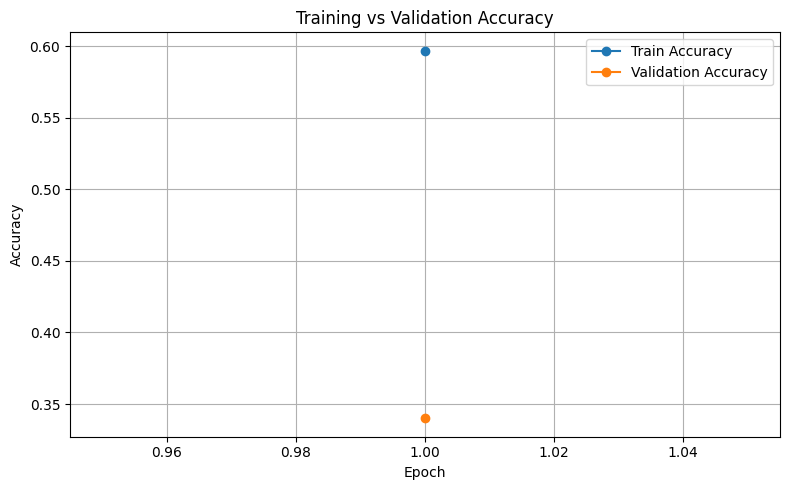

Test Accuracy: 0.3235


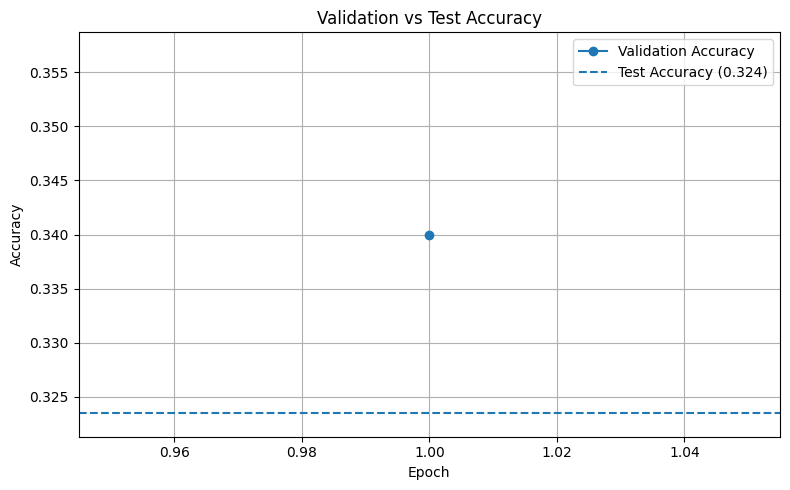

Pipeline completed successfully.


In [312]:
main()